In [65]:
!nvidia-smi

Mon Feb 16 23:26:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [66]:
# Initialize timing log file
LOG_FILE = "timing_log.txt"

def log_timing(label, output, has_kernel=False):
    """Log timing output to file with kernel indicator"""
    kernel_tag = "[GPU KERNEL]" if has_kernel else "[CPU ONLY]"
    with open(LOG_FILE, "a") as f:
        f.write(f"\n{'='*60}\n")
        f.write(f"{kernel_tag} {label}\n")
        f.write(f"{'='*60}\n")
        f.write(output + "\n")

# Clear log file at start of session
with open(LOG_FILE, "w") as f:
    f.write("CUDA Learning - Timing Log\n")
    f.write(f"Generated: {__import__('datetime').datetime.now()}\n")
    
print(f"Timing log initialized: {LOG_FILE}")

Timing log initialized: timing_log.txt


In [67]:
%%writefile hello.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <vector>

#define CHECK(call)                                   \
do {                                                  \
    cudaError_t err = call;                           \
    if (err != cudaSuccess) {                         \
        printf("CUDA error %s:%d: %s\n",              \
               __FILE__, __LINE__,                    \
               cudaGetErrorString(err));              \
        exit(1);                                      \
    }                                                 \
} while (0)

__global__ void vecAdd(float* A, float* B, float* C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        C[i] = A[i] + B[i];
    }
}

int main() {
    const int N = 1500000;

    std::vector<float> h_A(N), h_B(N), h_C(N);

    for (int i = 0; i < N; i++) {
        h_A[i] = float(i + 1);
        h_B[i] = float((i + 1) * 10);
    }

    float *d_A, *d_B, *d_C;
    CHECK(cudaMalloc(&d_A, N * sizeof(float)));
    CHECK(cudaMalloc(&d_B, N * sizeof(float)));
    CHECK(cudaMalloc(&d_C, N * sizeof(float)));

    CHECK(cudaMemcpy(d_A, h_A.data(), N * sizeof(float), cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B, h_B.data(), N * sizeof(float), cudaMemcpyHostToDevice));

    int blockSize = 512;
    int blocks = (N + blockSize - 1) / blockSize;
    vecAdd<<<blocks, blockSize>>>(d_A, d_B, d_C, N);

    CHECK(cudaGetLastError());
    CHECK(cudaDeviceSynchronize());

    CHECK(cudaMemcpy(h_C.data(), d_C, N * sizeof(float), cudaMemcpyDeviceToHost));

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

Overwriting hello.cu


In [68]:
!nvcc -arch=sm_70 hello.cu -o hello

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [69]:
import subprocess
result = subprocess.run("nvprof ./hello 2>&1", shell=True, capture_output=True, text=True)
output = result.stdout + result.stderr
print(output)
log_timing("Vector Addition (vecAdd kernel)", output, has_kernel=True)

==14899== NVPROF is profiling process 14899, command: ./hello
==14899== Profiling application: ./hello
==14899== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   66.65%  2.2174ms         2  1.1087ms  1.1057ms  1.1118ms  [CUDA memcpy HtoD]
                   31.17%  1.0369ms         1  1.0369ms  1.0369ms  1.0369ms  [CUDA memcpy DtoH]
                    2.18%  72.576us         1  72.576us  72.576us  72.576us  vecAdd(float*, float*, float*, int)
      API calls:   97.48%  257.13ms         3  85.710ms  65.526us  257.00ms  cudaMalloc
                    1.52%  4.0007ms         3  1.3336ms  1.3090ms  1.3701ms  cudaMemcpy
                    0.65%  1.7193ms       114  15.081us      83ns  879.88us  cuDeviceGetAttribute
                    0.26%  681.77us         3  227.26us  111.05us  285.81us  cudaFree
                    0.05%  143.92us         1  143.92us  143.92us  143.92us  cudaLaunchKernel
                    0.03%  7

CPU Vector Addition

In [70]:
%%writefile main.cpp
#include <iostream>
#include <chrono>
#include <vector>
using namespace std;

int main() {
  
  const int N = 1500000;
  std::vector<int> arr(N);
  for (int i = 0; i < N; i++) {
      arr[i] = i + 1;
  }
  std::vector<int>arr2(N);
  for (int i = 0; i < N; i++) {
    arr2[i] = (i + 1) * 10;
  }
  std::vector<int>arr3(N);
  auto start = std::chrono::high_resolution_clock::now();
  for (int i = 0; i < N; i++) {
    arr3[i] = arr[i] + arr2[i];
    //cout << "arr3[" << i << "] = " << arr3[i] << endl;
  }
  auto end = std::chrono::high_resolution_clock::now();
  auto us = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();
  std::cout << "CPU time: " << us << " ms\n";

  return 0;
}

Overwriting main.cpp


In [71]:
!g++ main.cpp -pg -o vector_naive
import subprocess
result = subprocess.run("./vector_naive", shell=True, capture_output=True, text=True)
output = result.stdout + result.stderr
print(output)
log_timing("Vector Addition (CPU)", output, has_kernel=False)

CPU time: 62 ms



Naive CUDA Matmul

In [72]:
%%writefile matmul.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <vector>
#include <iostream>
#include <cstdlib>

using namespace std;
#define CHECK(call)                                   \
do {                                                  \
    cudaError_t err = call;                           \
    if (err != cudaSuccess) {                         \
        printf("CUDA error %s:%d: %s\n",              \
               __FILE__, __LINE__,                    \
               cudaGetErrorString(err));              \
        exit(1);                                      \
    }                                                 \
} while (0)

__global__ void matmul(float *a, float *b, float *c, int N) {
  int column = blockIdx.x * blockDim.x + threadIdx.x;
  int row = blockIdx.y * blockDim.y + threadIdx.y;
  if (column < N && row < N) {
    float sum = 0;
    for (int i = 0; i < N; i++) {
      sum += a[row * N + i] * b[i * N + column];
    }
    c[row * N + column] = sum;
  }
}

int main(int argc, char *argv[]) {
    int N = 16;
    if (argc > 1) {
        N = atoi(argv[1]);
    }
    const int size = N * N;

    std::vector<float> h_A(size), h_B(size), h_C(size);

    for (int i = 0; i < size; i++) {
        h_A[i] = float(i + 1);
        h_B[i] = float(i + 1);
    }

    float *d_A, *d_B, *d_C;
    CHECK(cudaMalloc(&d_A, size * sizeof(float)));
    CHECK(cudaMalloc(&d_B, size * sizeof(float)));
    CHECK(cudaMalloc(&d_C, size * sizeof(float)));

    CHECK(cudaMemcpy(d_A, h_A.data(), size * sizeof(float), cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B, h_B.data(), size * sizeof(float), cudaMemcpyHostToDevice));

    dim3 blockDim(16, 16);
    dim3 gridDim((N + 15) / 16, (N + 15) / 16);
    matmul<<<gridDim, blockDim>>>(d_A, d_B, d_C, N);

    CHECK(cudaGetLastError());
    CHECK(cudaDeviceSynchronize());

    CHECK(cudaMemcpy(h_C.data(), d_C, size * sizeof(float), cudaMemcpyDeviceToHost));

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

Overwriting matmul.cu


In [73]:
!nvcc -arch=sm_70 matmul.cu -o matmul
import subprocess
result = subprocess.run("nvprof ./matmul 2>&1", shell=True, capture_output=True, text=True)
output = result.stdout + result.stderr
print(output)
log_timing("Matrix Multiplication - Naive (matmul kernel)", output, has_kernel=True)

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
==14964== NVPROF is profiling process 14964, command: ./matmul
==14964== Profiling application: ./matmul
==14964== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   54.38%  4.7680us         1  4.7680us  4.7680us  4.7680us  matmul(float*, float*, float*, int)
                   23.72%  2.0800us         1  2.0800us  2.0800us  2.0800us  [CUDA memcpy DtoH]
                   21.90%  1.9200us         2     960ns     736ns  1.1840us  [CUDA memcpy HtoD]
      API calls:   99.00%  273.55ms         3  91.184ms  2.0040us  273.55ms  cudaMalloc
                    0.90%  2.4894ms       114  21.836us      91ns  1.3554ms  cuDeviceGetAttribute
                    0.04%  117.62us         1  117.62us  117.62us  117.62us  cudaLaunchKernel
             

CPU Matmul

In [74]:
%%writefile matmul.cpp
#include <iostream>
#include <chrono>
#include <vector>
#include <cmath>

using namespace std;
using namespace std::chrono;

int main() {
  int N = 25;
  std::vector<int> arr(N);
  for (int i = 0; i < N; i++) {
      arr[i] = i + 1;
  }
  std::vector<int>arr2(N);
  for (int i = 0; i < N; i++) {
    arr2[i] = i + 1;
  }
  std::vector<int>arr3(N);
  int rows = static_cast<int>(sqrt(N));
  int columns = static_cast<int>(sqrt(N));
  auto start = high_resolution_clock::now();
  for (int i = 0; i < rows; i++) {
    for (int j = 0; j < columns; j++) {
      int sum = 0;
      for (int k = 0; k < rows; k++) {
        int matrix_1_index = k + (i * rows);
        int matrix_2_index = j + (k * columns);
        sum += arr[matrix_1_index] * arr2[matrix_2_index];
      }
      arr3[(i * rows) + j] = sum;
    }
    
  }
  auto end = high_resolution_clock::now();
  auto us = duration_cast<std::chrono::milliseconds>(end - start).count();
  std::cout << "CPU time: " << us << " ms\n";
  for (int i = 0; i < N; i++) {
    cout << "arr3[" << i << "] = " << arr3[i] << endl;
  }
  return 0;
}

Overwriting matmul.cpp


In [75]:
!g++ matmul.cpp -pg -o main
import subprocess
result = subprocess.run("./main", shell=True, capture_output=True, text=True)
output = result.stdout + result.stderr
print(output)
log_timing("Matrix Multiplication (CPU)", output, has_kernel=False)

CPU time: 0 ms
arr3[0] = 215
arr3[1] = 230
arr3[2] = 245
arr3[3] = 260
arr3[4] = 275
arr3[5] = 490
arr3[6] = 530
arr3[7] = 570
arr3[8] = 610
arr3[9] = 650
arr3[10] = 765
arr3[11] = 830
arr3[12] = 895
arr3[13] = 960
arr3[14] = 1025
arr3[15] = 1040
arr3[16] = 1130
arr3[17] = 1220
arr3[18] = 1310
arr3[19] = 1400
arr3[20] = 1315
arr3[21] = 1430
arr3[22] = 1545
arr3[23] = 1660
arr3[24] = 1775



Shared Memory + Tiling Matmul

In [76]:
%%writefile matmul_tiled.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <vector>
#include <iostream>
#include <cstdlib>

using namespace std;
#define CHECK(call)                                   \
do {                                                  \
    cudaError_t err = call;                           \
    if (err != cudaSuccess) {                         \
        printf("CUDA error %s:%d: %s\n",              \
               __FILE__, __LINE__,                    \
               cudaGetErrorString(err));              \
        exit(1);                                      \
    }                                                 \
} while (0)

#define TILE_SIZE 16

__global__ void matmul(float *a, float *b, float *c, int N) {
  __shared__ float tileA[TILE_SIZE][TILE_SIZE];
  __shared__ float tileB[TILE_SIZE][TILE_SIZE];
  
  int column = blockIdx.x * blockDim.x + threadIdx.x;
  int row = blockIdx.y * blockDim.y + threadIdx.y;
  
  float sum = 0;
  
  for (int tileIdx = 0; tileIdx < (N + TILE_SIZE - 1) / TILE_SIZE; tileIdx++) {
    int aCol = tileIdx * TILE_SIZE + threadIdx.x;
    int bRow = tileIdx * TILE_SIZE + threadIdx.y;
    
    // Bounds checking for loading
    tileA[threadIdx.y][threadIdx.x] = (row < N && aCol < N) ? a[row * N + aCol] : 0.0f;
    tileB[threadIdx.y][threadIdx.x] = (bRow < N && column < N) ? b[bRow * N + column] : 0.0f;
    
    __syncthreads();
    
    for (int k = 0; k < TILE_SIZE; k++) {
       sum += tileA[threadIdx.y][k] * tileB[k][threadIdx.x];
    }
    
    __syncthreads();
  }
  
  if (row < N && column < N) {
    c[row * N + column] = sum;
  }
}

int main(int argc, char *argv[]) {
    int N = 16;
    if (argc > 1) {
        N = atoi(argv[1]);
    }
    const int size = N * N;

    std::vector<float> h_A(size), h_B(size), h_C(size);

    for (int i = 0; i < size; i++) {
        h_A[i] = float(i + 1);
        h_B[i] = float(i + 1);
    }

    float *d_A, *d_B, *d_C;
    CHECK(cudaMalloc(&d_A, size * sizeof(float)));
    CHECK(cudaMalloc(&d_B, size * sizeof(float)));
    CHECK(cudaMalloc(&d_C, size * sizeof(float)));

    CHECK(cudaMemcpy(d_A, h_A.data(), size * sizeof(float), cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B, h_B.data(), size * sizeof(float), cudaMemcpyHostToDevice));

    dim3 blockDim(16, 16);
    dim3 gridDim((N + 15) / 16, (N + 15) / 16);
    matmul<<<gridDim, blockDim>>>(d_A, d_B, d_C, N);

    CHECK(cudaGetLastError());
    CHECK(cudaDeviceSynchronize());

    CHECK(cudaMemcpy(h_C.data(), d_C, size * sizeof(float), cudaMemcpyDeviceToHost));

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

Overwriting matmul_tiled.cu


In [77]:
!nvcc -arch=sm_70 matmul.cu -o matmul
!nvcc -arch=sm_70 matmul_tiled.cu -o matmul-tiled
print("Compiled both matmul versions")

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Compiled both matmul versions


## Naive vs Tiled Matmul Benchmark

In [90]:
import subprocess
import re
import matplotlib.pyplot as plt

def parse_time_value(time_str):
    """Convert time string like '4.51ms' or '327.08us' or '1.2s' to microseconds"""
    match = re.match(r'([\d.]+)(ms|us|ns|s)', time_str.strip())
    if not match:
        return None
    val = float(match.group(1))
    unit = match.group(2)
    if unit == 's':
        return val * 1_000_000
    elif unit == 'ms':
        return val * 1_000
    elif unit == 'us':
        return val
    elif unit == 'ns':
        return val / 1_000
    return None

def parse_kernel_time(nvprof_output):
    """Extract kernel execution time from nvprof output (in microseconds)"""
    for line in nvprof_output.split('\n'):
        if 'matmul(' in line:
            parts = line.split()
            for part in parts:
                if '%' in part:
                    continue
                if re.match(r'[\d.]+(ms|us|ns|s)$', part):
                    return parse_time_value(part)
    return None

def run_benchmark(executable, N):
    """Run nvprof on executable with matrix size N, return kernel time in us"""
    cmd = f"nvprof ./{executable} {N} 2>&1"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    output = result.stdout + result.stderr
    return parse_kernel_time(output), output

# Matrix sizes to test
sizes = [64, 128, 256, 512, 1024, 2048, 4096, 16384]

naive_times = []
tiled_times = []

print("Running benchmarks...")
print("-" * 50)

for N in sizes:
    print(f"Matrix size: {N}x{N}", end=" ... ")
    
    naive_time, _ = run_benchmark("matmul", N)
    tiled_time, _ = run_benchmark("matmul-tiled", N)
    
    naive_times.append(naive_time)
    tiled_times.append(tiled_time)
    
    if naive_time and tiled_time:
        speedup = naive_time / tiled_time
        print(f"Naive: {naive_time:.2f}us, Tiled: {tiled_time:.2f}us, Speedup: {speedup:.2f}x")
    else:
        print("FAILED")

# Log results to file
with open(LOG_FILE, "a") as f:
    f.write(f"\n{'='*60}\n")
    f.write("[GPU KERNEL] Matmul Benchmark Results\n")
    f.write(f"{'='*60}\n")
    f.write(f"{'Size':<12} {'Naive (us)':<15} {'Tiled (us)':<15} {'Speedup':<10}\n")
    f.write("-" * 52 + "\n")
    for i, N in enumerate(sizes):
        if naive_times[i] and tiled_times[i]:
            speedup = naive_times[i] / tiled_times[i]
            f.write(f"{N}x{N:<9} {naive_times[i]:<15.2f} {tiled_times[i]:<15.2f} {speedup:<10.2f}x\n")

print("\nResults logged to", LOG_FILE)

Running benchmarks...
--------------------------------------------------
Matrix size: 64x64 ... Naive: 7.68us, Tiled: 6.21us, Speedup: 1.24x
Matrix size: 128x128 ... Naive: 15.62us, Tiled: 11.74us, Speedup: 1.33x
Matrix size: 256x256 ... Naive: 79.07us, Tiled: 47.14us, Speedup: 1.68x
Matrix size: 512x512 ... Naive: 513.31us, Tiled: 326.02us, Speedup: 1.57x
Matrix size: 1024x1024 ... Naive: 5395.80us, Tiled: 3723.10us, Speedup: 1.45x
Matrix size: 2048x2048 ... Naive: 44450.00us, Tiled: 25329.00us, Speedup: 1.75x
Matrix size: 4096x4096 ... Naive: 324330.00us, Tiled: 192640.00us, Speedup: 1.68x
Matrix size: 16384x16384 ... Naive: 28574100.00us, Tiled: 14988100.00us, Speedup: 1.91x

Results logged to timing_log.txt


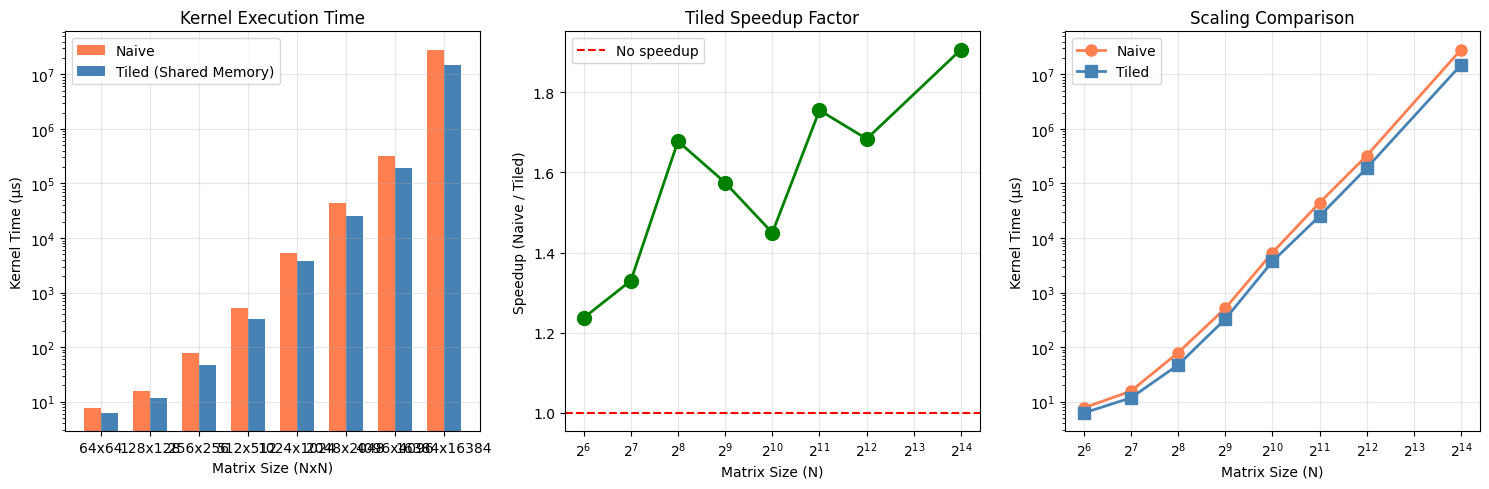

Graph saved to matmul_benchmark.png


In [91]:
# Filter out None values for plotting
valid_indices = [i for i in range(len(sizes)) if naive_times[i] and tiled_times[i]]
valid_sizes = [sizes[i] for i in valid_indices]
valid_naive = [naive_times[i] for i in valid_indices]
valid_tiled = [tiled_times[i] for i in valid_indices]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Kernel execution times (log scale)
ax1 = axes[0]
x = range(len(valid_sizes))
width = 0.35
ax1.bar([i - width/2 for i in x], valid_naive, width, label='Naive', color='coral')
ax1.bar([i + width/2 for i in x], valid_tiled, width, label='Tiled (Shared Memory)', color='steelblue')
ax1.set_xlabel('Matrix Size (NxN)')
ax1.set_ylabel('Kernel Time (μs)')
ax1.set_title('Kernel Execution Time')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{s}x{s}' for s in valid_sizes])
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Speedup factor
ax2 = axes[1]
speedups = [n/t for n, t in zip(valid_naive, valid_tiled)]
ax2.plot(valid_sizes, speedups, 'go-', linewidth=2, markersize=10)
ax2.axhline(y=1, color='r', linestyle='--', label='No speedup')
ax2.set_xlabel('Matrix Size (N)')
ax2.set_ylabel('Speedup (Naive / Tiled)')
ax2.set_title('Tiled Speedup Factor')
ax2.set_xscale('log', base=2)
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Time comparison
ax3 = axes[2]
ax3.plot(valid_sizes, valid_naive, 'o-', label='Naive', color='coral', linewidth=2, markersize=8)
ax3.plot(valid_sizes, valid_tiled, 's-', label='Tiled', color='steelblue', linewidth=2, markersize=8)
ax3.set_xlabel('Matrix Size (N)')
ax3.set_ylabel('Kernel Time (μs)')
ax3.set_title('Scaling Comparison')
ax3.set_xscale('log', base=2)
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matmul_benchmark.png', dpi=150)
plt.show()

print("Graph saved to matmul_benchmark.png")

In [80]:
# Display the complete timing log
print("="*60)
print("COMPLETE TIMING LOG")
print("="*60)
with open(LOG_FILE, "r") as f:
    print(f.read())

COMPLETE TIMING LOG
CUDA Learning - Timing Log
Generated: 2026-02-16 23:26:17.080428

[GPU KERNEL] Vector Addition (vecAdd kernel)
==14899== NVPROF is profiling process 14899, command: ./hello
==14899== Profiling application: ./hello
==14899== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   66.65%  2.2174ms         2  1.1087ms  1.1057ms  1.1118ms  [CUDA memcpy HtoD]
                   31.17%  1.0369ms         1  1.0369ms  1.0369ms  1.0369ms  [CUDA memcpy DtoH]
                    2.18%  72.576us         1  72.576us  72.576us  72.576us  vecAdd(float*, float*, float*, int)
      API calls:   97.48%  257.13ms         3  85.710ms  65.526us  257.00ms  cudaMalloc
                    1.52%  4.0007ms         3  1.3336ms  1.3090ms  1.3701ms  cudaMemcpy
                    0.65%  1.7193ms       114  15.081us      83ns  879.88us  cuDeviceGetAttribute
                    0.26%  681.77us         3  227.26us  111.05us  285.81us  